$$ W_{new} = W_{old} - \eta \times \frac{\partial L}{\partial W} $$

In [1]:
# 경사하강법(Gradient Decent)
 # 얼마나 틀렸는지 점수를 매기는 손실함수(Loss Function ) -->손실함수의 값이 최소(궁극적 목적은 0)
# 미분값(기울기) = (온도변화량 100)  / (손잡이 움직인 양 1) = 100

# 미분값(기울기) = (온도변화량 1)  / (손잡이 움직인 양 1) = 1
# 확률적(Stochastic)

# 학생이 공부한 시간 x1, 문제집 푼 갯수 x2 입력하면 시험합격여부 y(1, 0)
# z = W1 x (공부시간) + W2 x (문제집 푼 갯수) + b
# 무작위 뽑기와 초기화  W1 0.1  W2 0.5  b=0
# 스토케스틱 (무작위로 10만명중에 한명 뽑기)  A학생 5시간공부 2권풀고 합격 1


# z = (0.1 x 5) + (0.5 x 2) + 0 = 1.5
# 활성화 함수에 넣어서(시그모이드) 확률  80% 확률로 합격  0.8
# 나는 0.8로 예측  실제는 1.0  오차 0.2

# 미분을 통해 책임묻는다.. 공부를 5시간이나했는데. 가중치가 너무낮아서 예측을 맞추지 못했다
# 공식을 통해 업데이트 W_new = 0.1 - (0.01[학습률] x 기울기) = 0.12

# #####################################################################
# y = Wx + b  코드  y_pred = xi.dot(W) + b
# [공부시간 5시간, 문제집 2권] [가중치 0.1, 가중치 0.5]
# (5 * 0.1) + (2 * 0.5) 를 dot함수 하나로 깔끔하게 끝내

# 편미분 : 기울기(미분)는 변수 1개에 대한 변화량  변수가 많으면 구하고자 하는 변수를 제외하고는 상수취급해서 기울기를 구함

In [4]:
# 내적의 매력 : 여러특성을 한번에 병렬로 계산
# 3명 학생 특성은 2개(공부시간, 문제집수)
import numpy as np
x_students = np.array([ [5,2], [3,1], [8,4]   ])
#  모델의 가중치 W
w_stduents = np.array([ [0.1],[0.5]  ])

result_for = []
for x in x_students:
    score = x[0]*w_stduents[0,0] + x[1]*w_stduents[1,0]
    result_for.append(score)

print(result_for)

[np.float64(1.5), np.float64(0.8), np.float64(2.8)]


In [5]:
# 내적
x_students.dot(w_stduents)

array([[1.5],
       [0.8],
       [2.8]])

In [6]:
# 편미분  W1*x1 + W2*x2 수식에서 각 가중치(w)의 기울기를 단독으로 구하는 원리
x1, x2 = 2.0,3.0
w1, w2 = 1.0,1.0  # 현재 가중치(고정)
h = 0.0001  # 아주 미세한 변화량

# 원래 예측값
z_original = (w1*x1) + (w2*x2)
# 편미분1 : w2 고정하고 w1만 변경했을때 의 변화량
z_w1_change = ( (w1+h) *x1 ) + (w2*x2)
gradient_w1 =  (z_w1_change - z_original) / h

# 편미분2 : w1 고정하고 w2만 변경했을때 의 변화량
z_w2_change = ( w1 *x1 ) + ( (w2+h) *x2)
gradient_w2 =  (z_w2_change - z_original) / h

gradient_w1, gradient_w2

(1.9999999999953388, 3.00000000000189)

In [ ]:
# SGD 구현  임의의 선형 데이터 y = 3x + 4 를 생성해서 경사 하강법이 정답을 찾아가는 과정  y = wx + b
np.random.seed(42)
x = 2*np.random.rand(100,1)
y = 4 + 3*x + np.random.rand(100,1)  # 모델이 맞춰야할 정답 w=3  b = 4

w = np.random.randn(1,1)
b = np.random.randn(1,1)
epochs = 500
lr = 0.1

print(f' - 처음에 아무렇게나 찍은 무작위 가중치 : w = {w}, b = {b}')
for epoch in range(epochs):
    for i in range(100):
        random_index = np.random.randint(100)
        xi = x[random_index:random_index+1]
        yi = y[random_index:random_index+1]

        # 내적
        y_pred = xi.dot(w) + b
        error = y_pred - yi

        # 편미분을 이용해서 도함수(2*xi*error)
        # 손실함수  loss = (예측값 - 정답)**2  -->((w*x + b)-정답)**2  - 2*error -- 2*x*error
        gradient_w = 2*xi.T.dot(error)
        gradient_b = 2*error

        w = w - lr*gradient_w
        b = b - lr*gradient_b
print(f'50번의 훈련후  최정 가중치  w = {w}, b = {b}')

 - 처음에 아무렇게나 찍은 무작위 가중치 : w = [[-0.68002472]], b = [[0.2322537]]
50번의 훈련후  최정 가중치  w = [[3.13459488]], b = [[4.62869537]]


In [19]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784',version=1,as_frame=False)
x, y = mnist['data'], mnist['target']

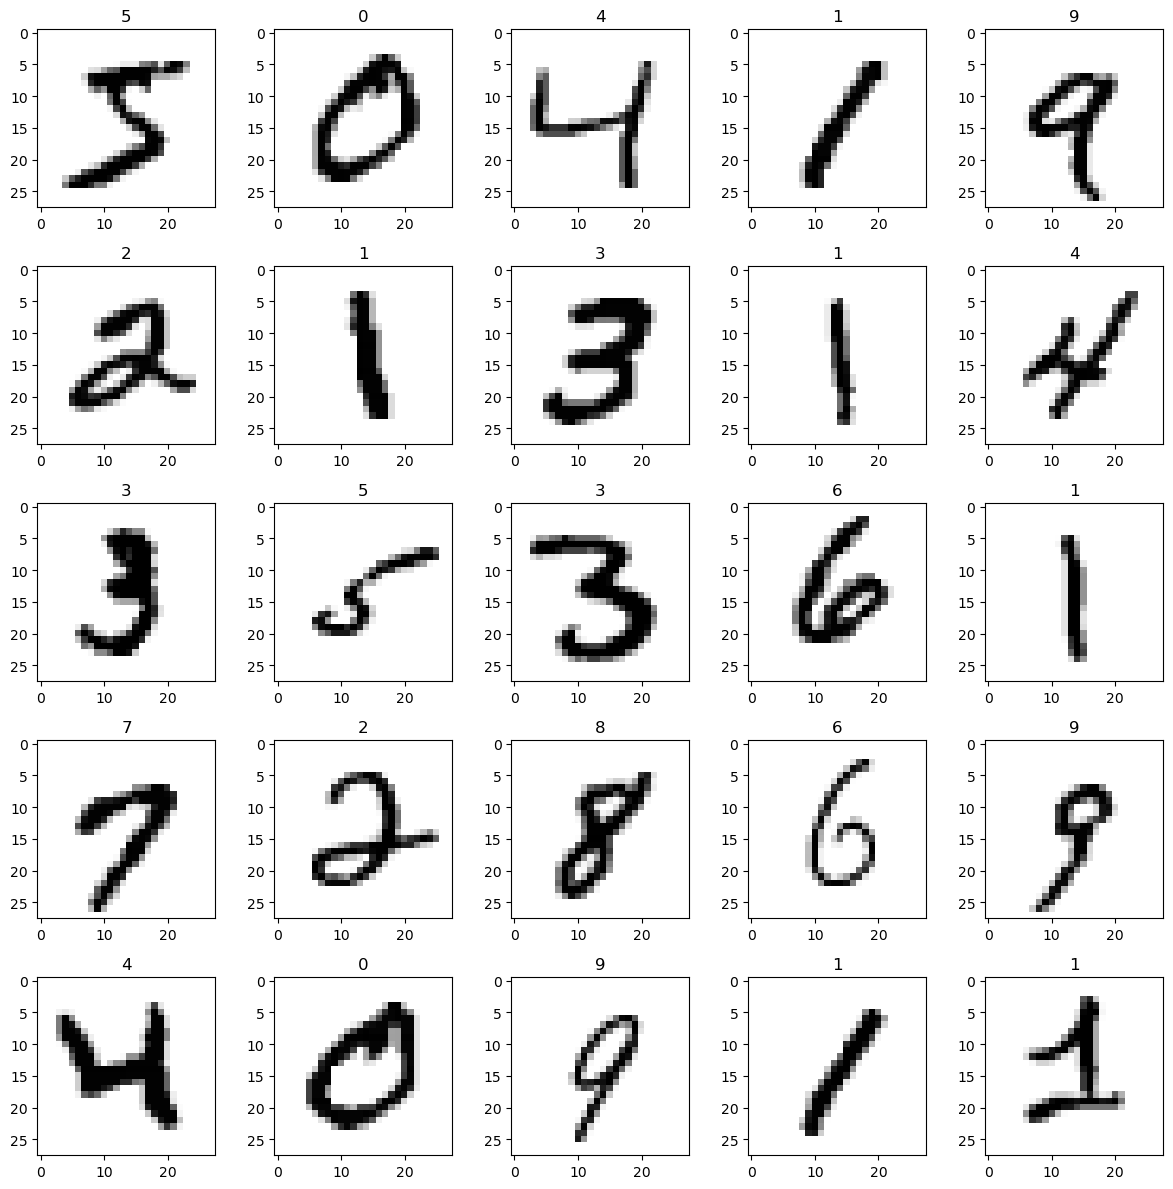

In [44]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(5,5,figsize=(12,12))
for i in range(25):
    axes[ i//5, i%5  ] .imshow(x[i].reshape(28,-1),cmap='gray_r')
    axes[ i//5, i%5  ].set_title(y[i])
plt.tight_layout()
plt.show()    

In [45]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier(random_state=42)
sgd.fit(x,y)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [46]:
sgd.score(x,y)

0.8942142857142857

In [48]:
sgd.predict(x[:25])

array(['3', '0', '4', '1', '9', '2', '1', '3', '1', '4', '3', '8', '3',
       '6', '1', '7', '2', '8', '6', '9', '4', '0', '9', '1', '3'],
      dtype='<U1')

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
sfk = StratifiedKFold(n_splits=5, shuffle=True)
scores = cross_val_score(SGDClassifier(random_state=42),x,y,cv=sfk)
score, score.mean()

In [3]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784',version=1,as_frame=False)
x, y = mnist['data'], mnist['target']

In [11]:
import numpy as np
y_5 = (y == '5')
x.shape, y_5.shape, np.unique(y_5)

((70000, 784), (70000,), array([False,  True]))

In [ ]:
y_train_pred = cross_val_predict(SGDClassifier(random_state=42), x, y_5,cv=3)

array([ True, False, False, ..., False,  True, False], shape=(70000,))

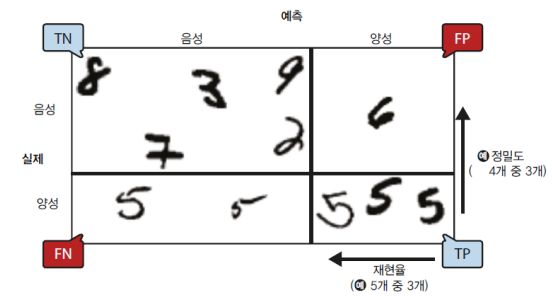

In [18]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_5, y_train_pred)
print(cm)
print(f'TN  5가 아님을 잘 맞춤 : {cm[0,0]} {cm[0,0] / len(y_5):.2f} ')
print(f'FP  모델이 5라고 예측했는데 아님...(5라고 억지부림) : {cm[0,1]} {cm[0,1] / len(y_5):.2f}')
print(f'FN  모델이 진짜 5를 놓침 : {cm[1,0]} {cm[1,0] / len(y_5):.2f}')
print(f'TP  5를 잘 맞춤 : {cm[1,1]} {cm[1,1] / len(y_5):.2f}')
print(f'정확도 : {(cm[0,0] + cm[1,1]) / len(y_5)}')

[[61910  1777]
 [ 1073  5240]]
TN  5가 아님을 잘 맞춤 : 61910 0.88 
FP  모델이 5라고 예측했는데 아님...(5라고 억지부림) : 1777 0.03
FN  모델이 진짜 5를 놓침 : 1073 0.02
TP  5를 잘 맞춤 : 5240 0.07
정확도 : 0.9592857142857143
